<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Relaxation_SBT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- DSMC Relaxation to Maxwell-Boltzmann Distribution (SBT Scheme) ---
Initializing particles with a UNIFORM random velocity distribution...
Velocities scaled to match initial temperature T_INIT = 273.0K.

Starting main simulation loop...
Step: 1000/10000...
Step: 2000/10000...
Step: 3000/10000...
Step: 4000/10000...
Step: 5000/10000...
Step: 6000/10000...
Step: 7000/10000...
Step: 8000/10000...
Step: 9000/10000...
Step: 10000/10000...
Simulation finished in 188.36 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 273.00 K
Plotting final speed distribution against theoretical curve at T_eq = 273.00K...


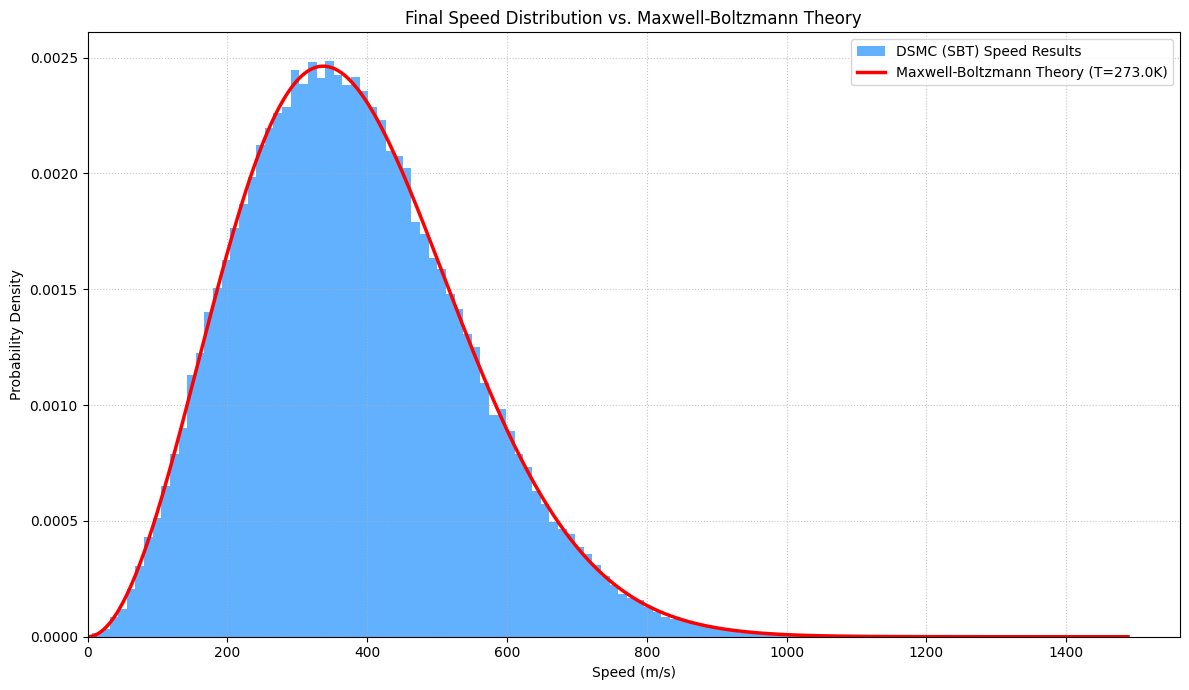

In [5]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION TO MAXWELL-BOLTZMANN (SBT MODEL) ---
# This version correctly simulates the relaxation of a non-equilibrium velocity
# distribution to the equilibrium Maxwell-Boltzmann distribution, using the SBT collision scheme.

import numpy as np
import matplotlib.pyplot as plt
import scipy.special
import numba
import time

# --- Constants and Physical Parameters ---
# Argon (Ar) properties
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
# VHS model parameters for Argon
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS (as per user request) ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0

NUM_CELLS_X = 40
PARTICLES_PER_CELL_INIT = 100  # User-defined particle count
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT

# Derived parameters
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X  # Assuming a cubic volume for FNUM calculation
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT

DT = 2.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_START_TIME = 5.0e-9 # Start sampling after some relaxation
SAMPLING_INTERVAL = 250 # Interval for collecting speed data

# --- Initialization Function ---
def initialize_particles_non_equilibrium():
    """Initializes particles with a uniform random velocity distribution."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    cell_width = LX / NUM_CELLS_X
    V_MAX_INITIAL = 800.0

    print("Initializing particles with a UNIFORM random velocity distribution...")
    # Vectorized position initialization (uniform spatial distribution)
    particles[:, 0] = np.random.rand(TOTAL_PARTICLES_SIM) * LX

    # Vectorized velocity initialization (uniform random distribution)
    particles[:, 1:4] = V_MAX_INITIAL * (2.0 * np.random.rand(TOTAL_PARTICLES_SIM, 3) - 1.0)

    # Scale velocities to match the target initial temperature
    current_ke = 0.5 * MASS_AR * np.sum(particles[:, 1:4]**2)
    target_ke = 1.5 * TOTAL_PARTICLES_SIM * KB * T_INIT
    scaling_factor = np.sqrt(target_ke / current_ke)
    particles[:, 1:4] *= scaling_factor

    print(f"Velocities scaled to match initial temperature T_INIT = {T_INIT}K.")
    return particles

# --- DSMC Core Functions (SBT Model) ---
@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@numba.jit(nopython=True)
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum):
    """Performs collisions in a cell using the Simplified Bernoulli Trials (SBT) scheme."""
    max_prob_in_step = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0

    prob_const = fnum * dt / cell_vol

    for i in range(num_particles_in_cell):
        for j in range(i + 1, num_particles_in_cell):
            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j]

            vrx = particles[p1_idx, 1] - particles[p2_idx, 1]
            vry = particles[p1_idx, 2] - particles[p2_idx, 2]
            vrz = particles[p1_idx, 3] - particles[p2_idx, 3]
            vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            collision_prob = prob_const * sigma_t * vr_mag
            if collision_prob > max_prob_in_step:
                max_prob_in_step = collision_prob

            if np.random.rand() < collision_prob:
                vcm_x = 0.5 * (particles[p1_idx, 1] + particles[p2_idx, 1])
                vcm_y = 0.5 * (particles[p1_idx, 2] + particles[p2_idx, 2])
                vcm_z = 0.5 * (particles[p1_idx, 3] + particles[p2_idx, 3])

                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()

                vr_prime_x = vr_mag * sin_chi * np.cos(phi_chi)
                vr_prime_y = vr_mag * sin_chi * np.sin(phi_chi)
                vr_prime_z = vr_mag * cos_chi

                particles[p1_idx, 1:4] = vcm_x + 0.5 * vr_prime_x, vcm_y + 0.5 * vr_prime_y, vcm_z + 0.5 * vr_prime_z
                particles[p2_idx, 1:4] = vcm_x - 0.5 * vr_prime_x, vcm_y - 0.5 * vr_prime_y, vcm_z - 0.5 * vr_prime_z

    return max_prob_in_step

# --- Plotting Function ---
def plot_speed_distribution(sampled_speeds, final_temp):
    """Plots the final speed distribution histogram against the theoretical Maxwell-Boltzmann curve."""
    print(f"Plotting final speed distribution against theoretical curve at T_eq = {final_temp:.2f}K...")
    plt.figure(figsize=(12, 7))
    plt.hist(sampled_speeds, bins=100, density=True, label='DSMC (SBT) Speed Results', alpha=0.7, color='dodgerblue')

    v_max_range = np.max(sampled_speeds) * 1.2
    v_theory = np.linspace(0, v_max_range, 500)
    # Maxwell-Boltzmann distribution formula
    pv_theory = ( (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * 4 * np.pi * v_theory**2
                  * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)) )

    plt.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann Theory (T={final_temp:.1f}K)')
    plt.xlabel('Speed (m/s)')
    plt.ylabel('Probability Density')
    plt.title('Final Speed Distribution vs. Maxwell-Boltzmann Theory')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

# --- Main Simulation ---
if __name__ == "__main__":
    print("--- DSMC Relaxation to Maxwell-Boltzmann Distribution (SBT Scheme) ---")

    particles = initialize_particles_non_equilibrium()

    # --- Data storage for distribution analysis ---
    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)

    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX  # Periodic boundary condition

        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        sorted_particle_indices = np.argsort(cell_indices)
        cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
        cell_start_indices = np.concatenate(([0], np.cumsum(cell_counts[:-1])))

        current_max_prob = 0.0
        for i in range(NUM_CELLS_X):
            start = cell_start_indices[i]
            end = start + cell_counts[i]
            indices_in_cell_i = sorted_particle_indices[start:end]
            max_p = perform_collisions_sbt_numba(
                particles, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM
            )
            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        # Sample speeds after the initial relaxation period
        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    # --- Final Analysis ---
    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    # --- Plot the final distribution ---
    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")